<img src=../figures/Brown_logo.svg width=50%>

## Data-Driven Design & Analyses of Structures & Materials (3dasm)

## Lecture 1

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor

## Introduction

**What:** A lecture of the "3dasm" course

**Where:** This notebook comes from this [repository](https://github.com/bessagroup/3dasm_course)

**Reference for entire course:** Murphy, Kevin P. *Probabilistic machine learning: an introduction*. MIT press, 2022. Available online [here](https://probml.github.io/pml-book/book1.html)

**How:** We try to follow Murphy's book closely, but the sequence of Chapters and Sections is different. The intention is to use notebooks as an introduction to the topic and Murphy's book as a resource.
* If working offline: Go through this notebook and read the book.
* If attending class in person: listen to me (!) but also go through the notebook in your laptop at the same time. Read the book.
* If attending lectures remotely: listen to me (!) via Zoom and (ideally) use two screens where you have the notebook open in 1 screen and you see the lectures on the other. Read the book.

**Optional reference (the "bible" by the "bishop"... pun intended 😆) :** Bishop, Christopher M. *Pattern recognition and machine learning*. Springer Verlag, 2006.

**References/resources to create this notebook:**
* [Figure (Car stopping distance)](https://korkortonline.se/en/theory/reaction-braking-stopping/)
* Snippets of code from this awesome [repo](https://github.com/gerdm/prml) by Gerardo Duran-Martin that replicates many figures in Bishop's book

Apologies in advance if I missed some reference used in this notebook. Please contact me if that is the case, and I will gladly include it here.

## **OPTION 1**. Run this notebook **locally in your computer**:

This is **only possible if you correctly installed all necessary packages** in the '3dasm' virtual environment.

* Installation instructions are available in the [course home page](https://github.com/bessagroup/3dasm_course).

If you have all packages already installed:

1. Open a (mamba) command window, activate the '3dasm' environment and start jupyter notebook (it will open in your internet browser):
```
mamba activate 3dasm
jupyter notebook
``` 
2. Open notebook (*3dasm_course/Lectures/Lecture01/3dasm_Lecture1.ipynb*)

You're all set!

## **OPTION 2**. Use **Google's Colab** (no installation required, but times out if idle):

1. go to https://colab.research.google.com
2. login
3. File > Open notebook
4. click on Github (no need to login or authorize anything)
5. paste the git link: https://github.com/bessagroup/3dasm_course
6. click search and then click on the notebook (*3dasm_course/Lectures/Lecture01/3dasm_Lecture1.ipynb*)

In [1]:
# These are basic plotting tools needed in Python.

import matplotlib.pyplot as plt # import plotting tools to create figures
import numpy as np # import numpy to handle a lot of things!

%config InlineBackend.figure_format = "retina" # render higher resolution images in the notebook
plt.rcParams["figure.figsize"] = (8,4) # rescale figure size appropriately for slides

## Course goals

- First half of the course (more theoretical):
    - Introducing machine learning from a probabilistic perspective.
        * Ends with a **Midterm** taken in class.

- Second half of the course (more practical):
    - Introducing the data-driven process.
        * Ends with a **Final project**.

## Grading
- Homeworks 10%, Midterm 40%, and Final Project 50%.

## Office hours

- Miguel Bessa (Instructor):
    - You can schedule an appointment using the link provided in the [CANVAS course page](https://canvas.brown.edu/).
    - Office B&H 731
- Teaching Assistants:
    - See [CANVAS course page](https://canvas.brown.edu/) for details.
    

## Outline for today

* Introduction
    - Taking a probabilistic perspective on machine learning
* Basics of univariate statistics
    - Continuous random variables
    - Probabilities vs probability densities

**Reading material**: This notebook + Chapter 2 until Section 2.3

## Get hyped about Artificial Intelligence...

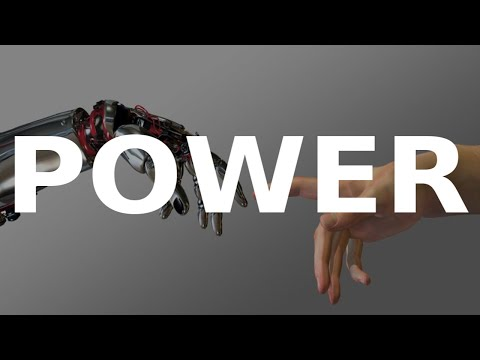

In [2]:
from IPython.display import display, YouTubeVideo, HTML
YouTubeVideo('RNnZwvklwa8', width=512, height=288) # show that slides are interactive:
                                                   # rescale video to 768x432 and back to 512x288

**Well...** This class *might* not make you break the world (yet!). We start by focusing on the fundamentals:

* Probabilistic perspective on machine learning
* Supervised learning (especially regression)

## Machine learning (ML)

* **ML definition**: A computer program that learns from experience $E$ wrt tasks $T$ such that the performance $P$ at those tasks improves with experience $E$.

* What does it mean to treat ML from a **probabilistic perspective**?
    - Treat all unknown quantities as **random variables**

* What are random variables?
    - Variables endowed with probability distributions!

## The car stopping distance problem

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="50%" align="right">

<br></br>
Car stopping distance ${\color{red}y}$ as a function of its velocity ${\color{green}x}$ before it starts braking:

${\color{red}y} = {\color{blue}z} x + \frac{1}{2\mu_{\text{fr}} g} {\color{green}x}^2 = {\color{blue}z} x + 0.1 {\color{green}x}^2$

- ${\color{blue}z}$ is the driver's reaction time (in seconds)
- $\mu_{\text{fr}}$ is the road/tires coefficient of friction (assume $\mu_{\text{fr}}=0.5$)
- $g$ is the acceleration of gravity (assume $g=10$ m/s$^2$).

<div class="alert alert-block alert-info"><b>Remark: Jupyter Notebooks can contain <font color=red>notes</font> not shown when in presentation mode. (See below)</div>

## The car stopping distance problem

### How to obtain this formula?

$y = d_r + d_{b}$

where $d_r$ is the reaction distance, and $d_b$ is the braking distance.

### Reaction distance $d_r$

$d_r = z x$

with $z$ being the driver's reaction time, and $x$ being the velocity of the car at the start of braking.

## The car stopping distance problem

### Braking distance $d_b$

Kinetic energy of moving car:

$E = \frac{1}{2}m x^2$ &nbsp; &nbsp; &nbsp; where $m$ is the car mass.

Work done by braking:

$W = \mu_{\text{fr}} m g d_b$ &nbsp; &nbsp; &nbsp; where $\mu_{\text{fr}}$ is the coefficient of friction between the road and the tire, $g$ is the acceleration of gravity, and $d_b$ is the car braking distance.

The braking distance follows from $E=W$:

$d_b = \frac{1}{2\mu_{\text{fr}} g}x^2$

Therefore, if we add the reacting distance $d_r$ to the braking distance $d_b$ we get the stopping distance $y$:

$$y = d_r + d_b = z x + \frac{1}{2\mu_{\text{fr}} g} x^2$$

## The car stopping distance problem

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="25%" align="right">

$y = {\color{blue}z} x + 0.1 x^2$

The driver's reaction time ${\color{blue}z}$ is a **random variable (rv)**

* Every driver has its own reaction time $z$

* Assume the distribution associated to $z$ is Gaussian with **mean** $\mu_z=1.5$ seconds and **variance** $\sigma_z^2=0.5^2$ seconds$^2$

$$
z \sim \mathcal{N}(\mu_z=1.5,\sigma_z^2=0.5^2)
$$

where $\sim$ means "sampled from", and $\mathcal{N}$ indicates a Gaussian **probability density function (pdf)**

## Univariate Gaussian <a title="probability density function">pdf</a> 

The Gaussian <a title="probability density function">pdf</a> is defined as:

$$
    \mathcal{N}(z | \mu_z, \sigma_z^2) = \frac{1}{\sqrt{2\pi\sigma_z^2}}e^{-\frac{1}{2\sigma_z^2}(z - \mu_z)^2}
$$

Alternatively, we can write it using the **precision** term $\lambda_z := 1 / \sigma_z^2$ instead of using $\sigma_z^2$:

$$
    \mathcal{N}(z | \mu_z, \lambda_z^{-1}) = \frac{\lambda_z^{1/2}}{\sqrt{2\pi}}e^{-\frac{\lambda_z}{2}(z - \mu_z)^2}
$$

Anyway, recall how this <a title="probability density function">pdf</a> looks like...

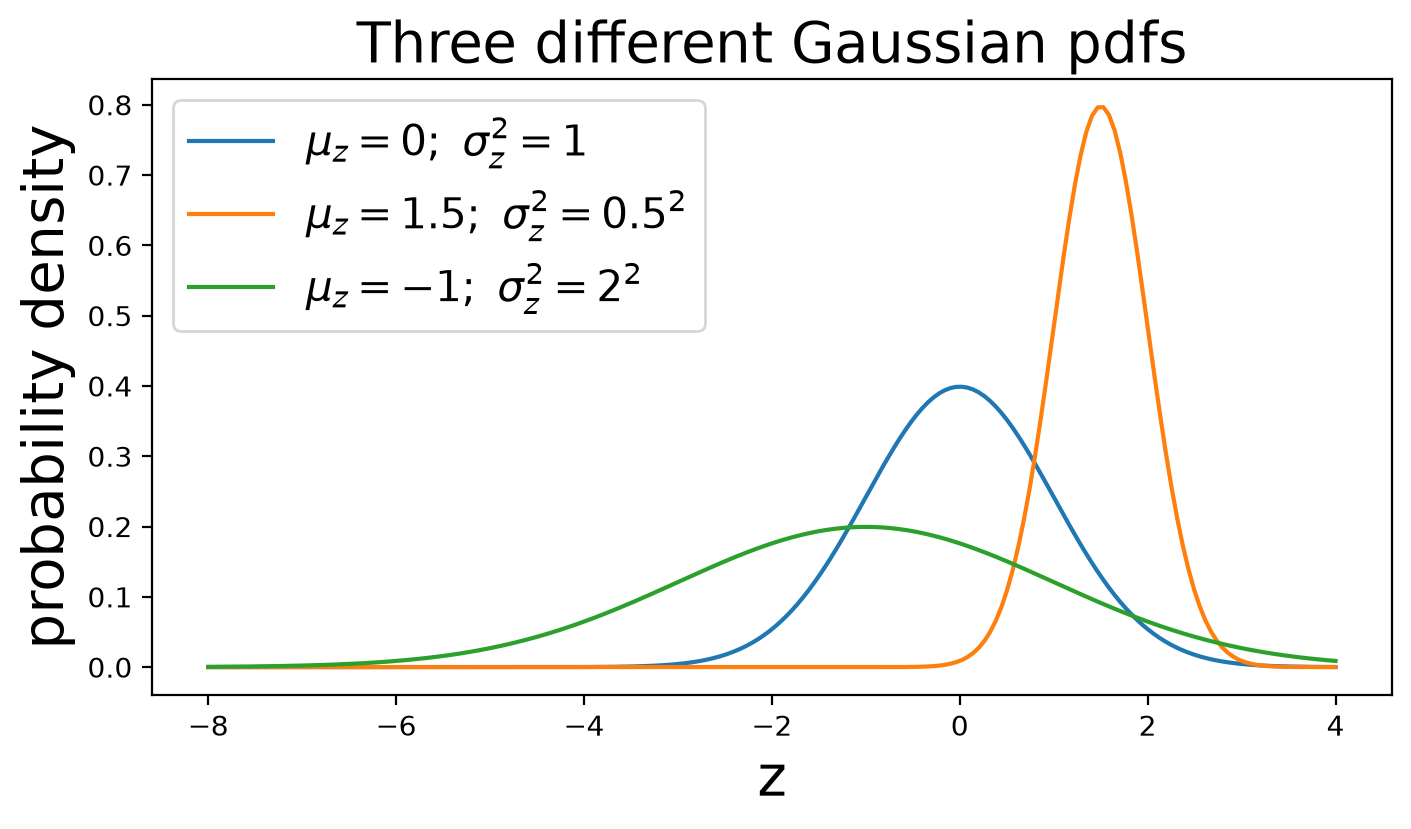

In [3]:
def norm_pdf(z, mu_z, sigma_z2): return 1/np.sqrt(2*np.pi*sigma_z2)*np.exp(-(z-mu_z)**2/(2*sigma_z2))
zrange = np.linspace(-8, 4, 200) # create a list of 200 z points between z=-8 and z=4
fig, ax = plt.subplots() # create a plot
ax.plot(zrange, norm_pdf(zrange, 0, 1), label=r"$\mu_z=0; \ \sigma_z^2=1$") # plot norm_pdf(z|0,1)
ax.plot(zrange, norm_pdf(zrange, 1.5, 0.5**2), label=r"$\mu_z=1.5; \ \sigma_z^2=0.5^2$") # plot norm_pdf(z|1.5,0.5^2)
ax.plot(zrange, norm_pdf(zrange, -1, 2**2), label=r"$\mu_z=-1; \ \sigma_z^2=2^2$") # plot norm_pdf(z|-1,2^2)
ax.set_xlabel("z", fontsize=20) # create x-axis label with font size 20
ax.set_ylabel("probability density", fontsize=20) # create y-axis label with font size 20
ax.legend(fontsize=15) # create legend with font size 15
ax.set_title("Three different Gaussian pdfs", fontsize=20); # create title with font size 20

The <span style="color:orange">orange</span> curve shows the Gaussian <a title="probability density function">pdf</a> of the <a title="random variable">rv</a> $z$ **conditioned** on the mean $\mu_z=1.5$ and variance $\sigma_z^2=0.5^2$ for the car stopping distance problem.

## Univariate Gaussian <a title="probability density function">pdf</a> 

$$
    p(z) = \mathcal{N}(z | \mu_z, \sigma_z^2) = \frac{1}{\sqrt{2\pi\sigma_z^2}}e^{-\frac{1}{2\sigma_z^2}(z - \mu_z)^2}
$$

The output of this expression is the **PROBABILITY DENSITY** of $z$ **given** (or conditioned to) a particular $\mu_z$ and $\sigma_z^2$.

* **Important**: Probability Density $\neq$ Probability

So, what is a probability?

## Probability

The probability of an event $A$ is denoted by $\text{Pr}(A)$.

* $\text{Pr}(A)$ means the probability with which we believe event A is true

* An event $A$ is a binary variable saying whether or not some state of the world holds.

Probability is defined such that: $0 \leq \text{Pr}(A) \leq 1$

where $\text{Pr}(A)=1$ if the event will definitely happen and $\text{Pr}(A)=0$ if it definitely will not happen.

## Joint probability

**Joint probability** of two events: $\text{Pr}(A \wedge B)= \text{Pr}(A, B)$

If $A$ and $B$ are **independent**: $\text{Pr}(A, B)= \text{Pr}(A) \text{Pr}(B)$

For example, suppose $z_1$ and $z_2$ are chosen uniformly at random from the set $\mathcal{Z} = \{1, 2, 3, 4\}$.

Let $A$ be the event that $z_1 \in \{1, 2\}$ and $B$ be the event that **another** <a title="random variable">rv</a> denoted as $z_2 \in \{3\}$.

Then we have: $\text{Pr}(A, B) = \text{Pr}(A) \text{Pr}(B) = \frac{1}{2} \cdot \frac{1}{4}$.

## Probability of a union of two events

Probability of event $A$ or $B$ happening is: $\text{Pr}(A \vee B)= \text{Pr}(A) + \text{Pr}(B) - \text{Pr}(A \wedge B)$

If these events are mutually exclusive (they can't happen at the same time):

$$
\text{Pr}(A \vee B)= \text{Pr}(A) + \text{Pr}(B)
$$

For example, suppose an <a title="random variable">rv</a> denoted as $z_1$ is chosen uniformly at random from the set $\mathcal{Z} = \{1, 2, 3, 4\}$.

Let $A$ be the event that $z_1 \in \{1, 2\}$ and $B$ be the event that the **same** <a title="random variable">rv</a> $z_1 \in \{3\}$.

Then we have $\text{Pr}(A \vee B) = \frac{2}{4} + \frac{1}{4}$.

## Conditional probability of one event given another

We define the **conditional probability** of event $B$ happening given that $A$ has occurred as follows:

$$
\text{Pr}(B | A)= \frac{\text{Pr}(A,B)}{\text{Pr}(A)}
$$

This is not defined if $\text{Pr}(A) = 0$, since we cannot condition on an impossible event.

## Conditional independence of two events given a third

We say that events $A$ and $B$ are **conditionally independent given** an event $C$ if

$$
\text{Pr}(A, B \mid C) = \text{Pr}(A \mid C)\, \text{Pr}(B \mid C)
$$

In words: once we know that $C$ happened, knowing whether $B$ happened tells us nothing more about $A$ (and vice versa).

The book uses the notation $A \perp B \mid C$ to denote this property.

* Compare with (unconditional) independence, $A \perp B$, which we saw two slides ago: $\text{Pr}(A, B) = \text{Pr}(A)\, \text{Pr}(B)$. Neither property implies the other.

## Coming back to our car stopping distance problem

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="25%" align="right">

$y = {\color{blue}z} x + 0.1 x^2$

where $z$ is a **continuous** <a title="random variable">rv</a> such that $z \sim \mathcal{N}(\mu_z=1.5,\sigma_z^2=0.5^2)$.

* What is the probability of an event $Z$ defined by a reaction time $z \leq 0.52$ seconds?

$$
\text{Pr}(Z)=\text{Pr}(z \leq 0.52)= P(0.52)
$$

where $P(z)$ denotes the **cumulative distribution function (cdf)**. Note that <a title="cumulative distribution function">cdf</a> is denoted with a capital $P$.

Likewise, we can compute the probability of being in any interval as follows:

$\text{Pr}(a \leq z \leq b)= P(b)-P(a)$

* But how do we compute the cdf at a particular value $b$, e.g. $P(b)$?

## <a title="Cumulative distribution functions">Cdf's</a> result from <a title="probability density functions">pdf's</a>

A <a title="probability density functions">pdf</a> $p(z)$ is defined as the derivative of the <a title="cumulative distribution functions">cdf</a> $P(z)$:

$$
p(z)=\frac{d}{d z}P(z)
$$

So, given a <a title="probability density function">pdf</a> $p(z)$, we can compute the following probabilities:

$$\text{Pr}(z \leq b)=\int_{-\infty}^b p(z) dz = P(b)$$
$$\text{Pr}(z \geq a)=\int_a^{\infty} p(z) dz = 1 - P(a)$$
$$\text{Pr}(a \leq z \leq b)=\int_a^b p(z) dz = P(b) - P(a)$$

**IMPORTANT**: $\int_{-\infty}^{\infty} p(z) dz = 1$

### Some notes about <a title="probability density functions">pdf's</a>

The integration to unity is important!

$$\int_{-\infty}^{\infty} p(z) dz = 1$$

**Remember:** the integral of a <a title="probability density function">pdf</a> leads to a probability, and probabilities cannot be larger than 1.

For example, from this property we can derive the following:

$$
\int_{-\infty}^{\infty} p(z) dz = \int_{-\infty}^{a} p(z) dz + \int_{a}^{\infty} p(z) dz
$$

$$
\Rightarrow \text{Pr}(z \geq a)= 1 - \text{Pr}(z \leq a) = 1 - \text{P}(a) = 1 - \int_{-\infty}^a p(z) dz
$$

In some cases we will work with probability distributions that are **unnormalized**, so this comment is important!

* Being unnormalized means that the probability density of the distribution does not integrate to 1.
* In this case, we cannot call such function a <a title="probability density function">pdf</a>, even though its output is a probability density.

## <a title="Cumulative distribution functions">Cdf's</a> result from <a title="probability density functions">pdf's</a>

Key point?

* Given a <a title="probability density function">pdf</a> $p(z)$, we can compute the probability of a continuous <a title="random variable">rv</a> $z$ being in a finite interval as follows:

$$
\text{Pr}(a \leq z \leq b)=\int_a^b p(z) dz = P(b) - P(a)
$$

As the size of the interval gets smaller, we can write

$$
\text{Pr}\left(z - \frac{dz}{2} \leq z \leq z + \frac{dz}{2}\right) \approx p(z) dz
$$

Intuitively, this says the probability of $z$ being in a small interval around $z$ is the density at $z$ times
the width of the interval.

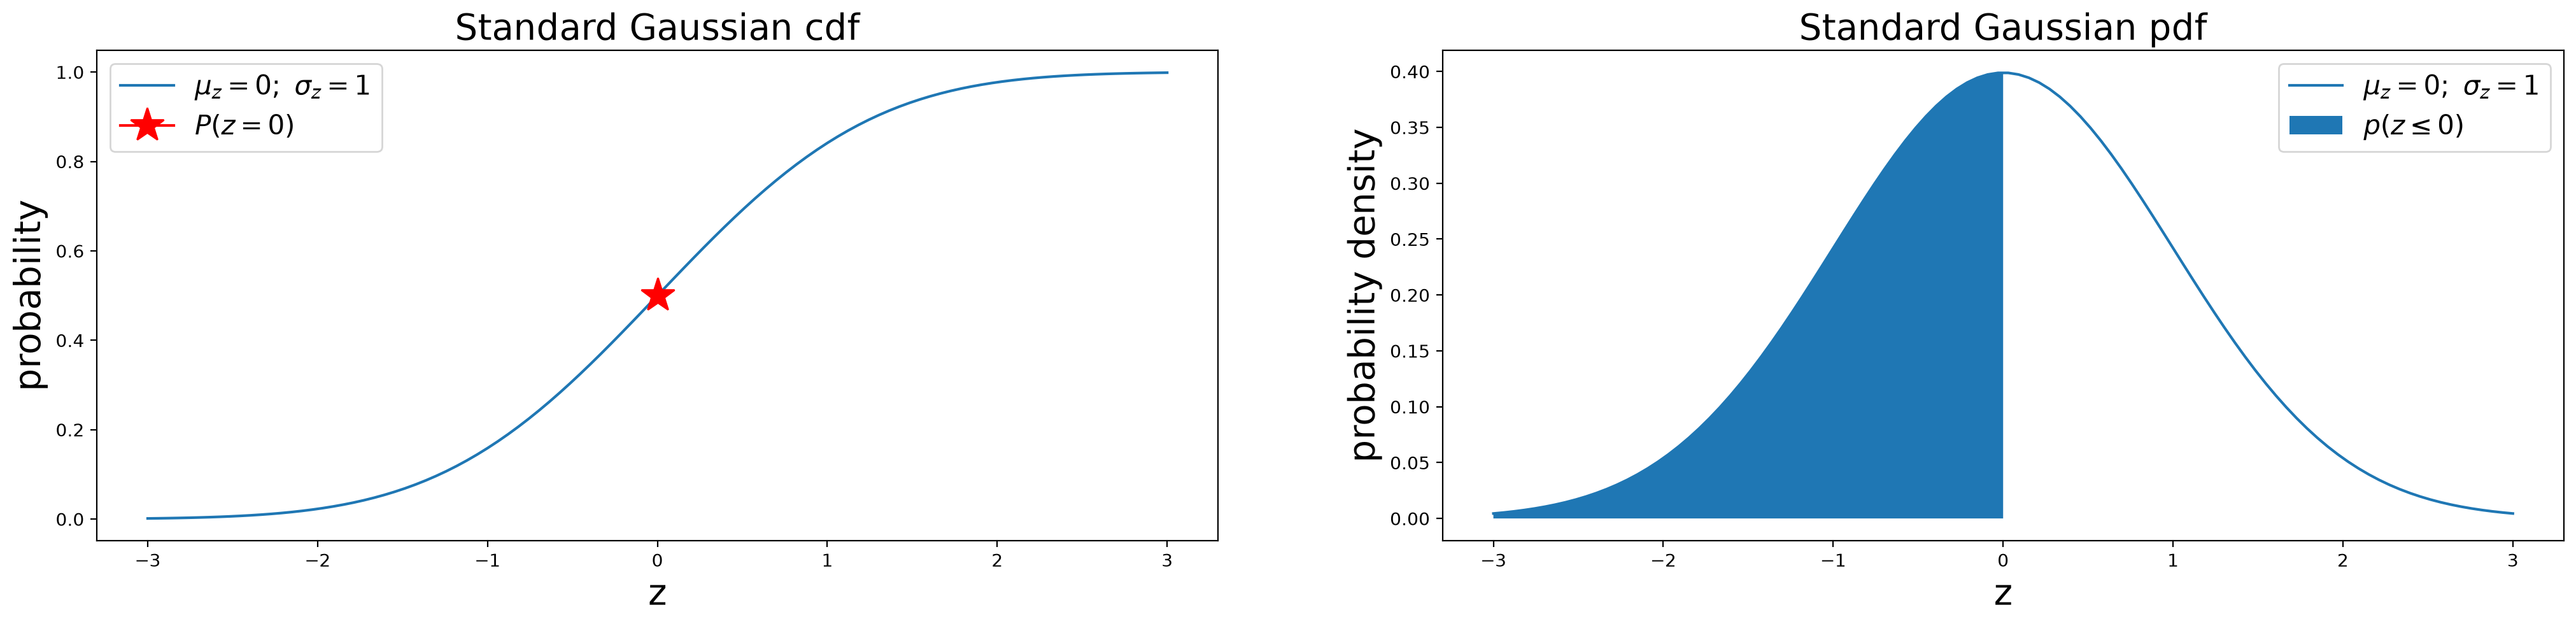

In [4]:
from scipy.stats import norm # import from scipy.stats the normal distribution

zrange = np.linspace(-3, 3, 100) # 100 values for plot
fig_std_norm, (ax1, ax2) = plt.subplots(1, 2) # create a plot with 2 subplots side-by-side
ax1.plot(zrange, norm.cdf(zrange, 0, 1), label=r"$\mu_z=0; \ \sigma_z=1$") # plot cdf of standard normal
ax1.plot(0, norm.cdf(0, 0, 1), marker='*', label=r'$P(0)$', markersize=20, color='r') #For the red marker
ax1.set_xlabel("z", fontsize=20)
ax1.set_ylabel("probability", fontsize=20)
ax1.legend(fontsize=15)
ax1.set_title("Standard Gaussian cdf", fontsize=20)

ax2.plot(zrange, norm.pdf(zrange, 0, 1), label=r"$\mu_z=0; \ \sigma_z=1$") # plot pdf of standard normal
ax2.fill_between(np.linspace(-3, 0, 100), norm.pdf(np.linspace(-3, 0, 100), 0, 1), # continues next line!
                 label = r'$\mathrm{Pr}(z \leq 0)$' ) # To fill the area under the curve
ax2.set_xlabel("z", fontsize=20)
ax2.set_ylabel("probability density", fontsize=20)
ax2.legend(fontsize=15)
ax2.set_title("Standard Gaussian pdf", fontsize=20)
fig_std_norm.set_size_inches(25, 5) # scale figure to be wider (since there are 2 subplots)

## Note about scipy.stats

[scipy](https://docs.scipy.org/doc/scipy/index.html) is an open-source software for mathematics, science, and engineering. It's brilliant and widely used for many things!

**In particular**, [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html) is a simple module within scipy that has statistical functions and operations that are very useful. This way, we don't need to code all the functions ourselves. That's why we are using it to plot the cdf and pdf of the Gaussian distribution from now on, and we will use it for other things later.

* In case you are interested, scipy.stats has a nice [tutorial](https://docs.scipy.org/doc/scipy/tutorial/stats.html)

## Coming back to our car stopping distance problem

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="25%" align="right">

$y = {\color{blue}z} x + 0.1 x^2$

where $z$ is a continuous <a title="random variable">rv</a> such that $p(z)= \mathcal{N}(z | \mu_z=1.5,\sigma_z^2=0.5^2)$.

* What is the probability of an event $Z$ defined by a reaction time $z \leq 0.52$ seconds?

$$
\text{Pr}(Z) = \text{Pr}(z \leq 0.52) = P(0.52) = \int_{-\infty}^{0.52} p(z) dz
$$

In [5]:
Pr_Z = norm.cdf(0.52, 1.5, 0.5) # using scipy norm.cdf(z=0.52 | mu_z=1.5, sigma_z=0.5)

print("The probability of event Z is: Pr(Z) = ",round(Pr_Z,3))

The probability of event Z is: Pr(Z) =  0.025


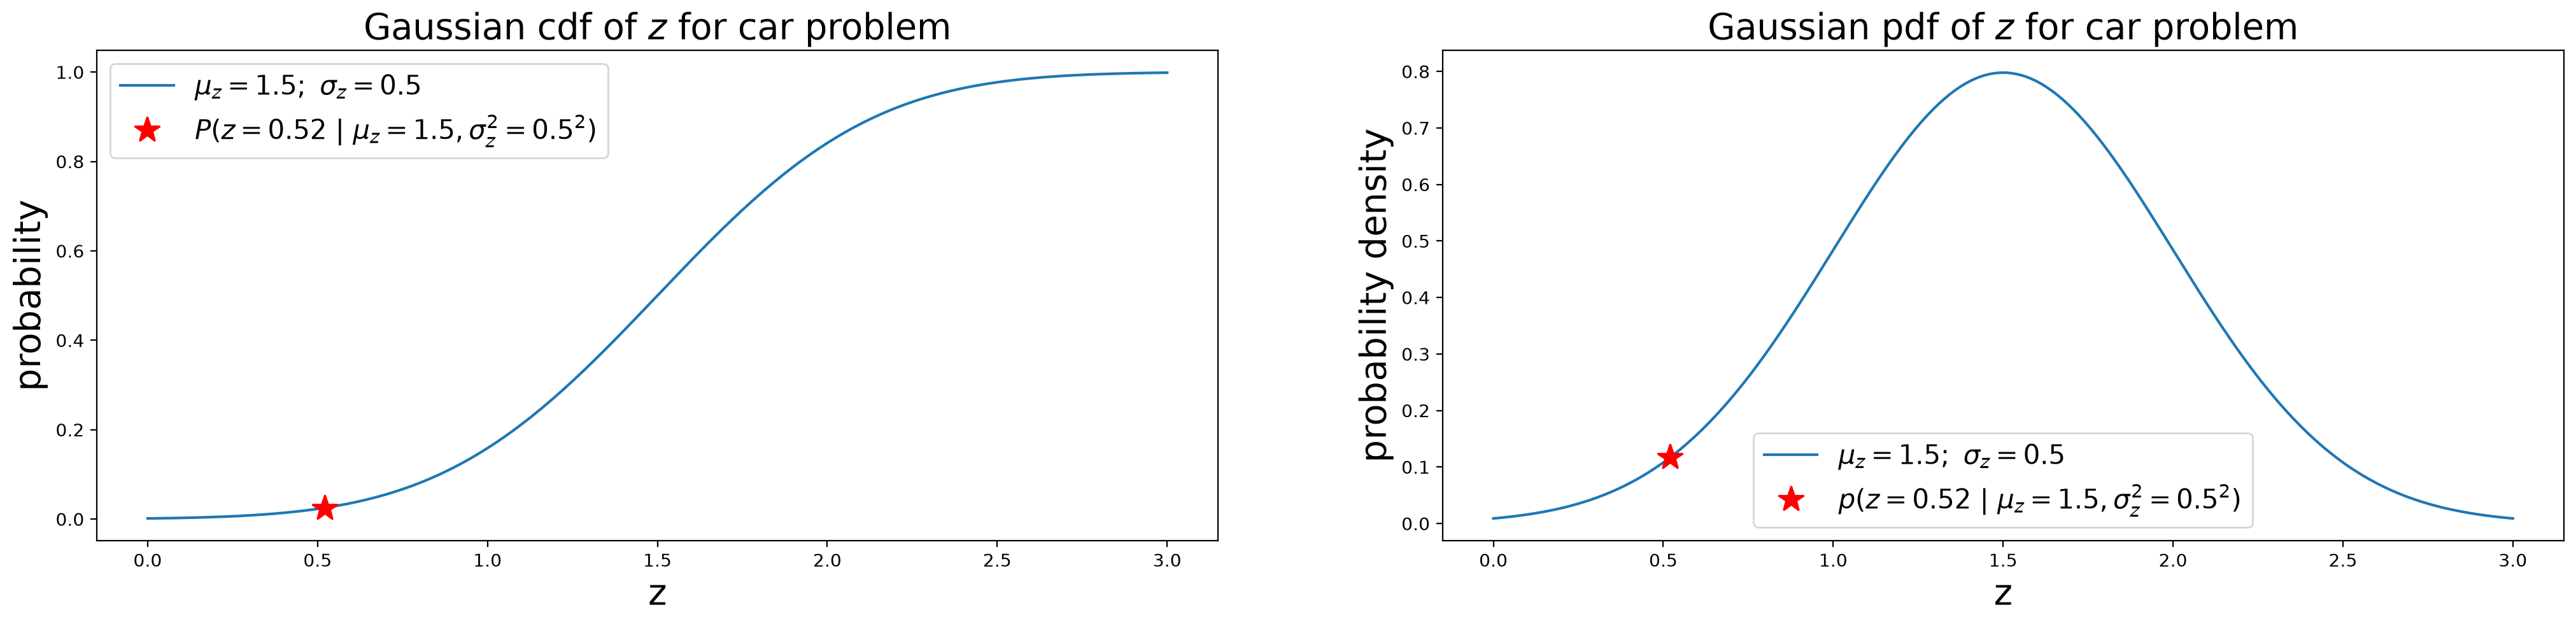

In [6]:
z_value = 0.52 # z = 0.52 seconds
zrange = np.linspace(0, 3, 200) # 200 values for plot
fig_car_norm, (ax1, ax2) = plt.subplots(1, 2) # create subplot (two figures in 1)
ax1.plot(zrange, norm.cdf(zrange, 1.5, 0.5), label=r"$\mu_z=1.5; \ \sigma_z=0.5$") # Figure 1 is cdf
ax1.plot(z_value, norm.cdf(z_value, 1.5, 0.5), 'r*',markersize=15, linewidth=2,
         label=r'$P(0.52~|~\mu_z=1.5, \sigma_z^2=0.5^2)$')
ax1.set_xlabel("z", fontsize=20)
ax1.set_ylabel("probability", fontsize=20)
ax1.legend(fontsize=15)
ax1.set_title("Gaussian cdf of $z$ for car problem", fontsize=20)
ax2.plot(zrange, norm.pdf(zrange, 1.5, 0.5), label=r"$\mu_z=1.5; \ \sigma_z=0.5$") # figure 2 is pdf
ax2.plot(z_value, norm.pdf(z_value, 1.5, 0.5), 'r*', markersize=15, linewidth=2,
         label=r'$p(z=0.52~|~\mu_z=1.5, \sigma_z^2=0.5^2)$')
ax2.set_xlabel("z", fontsize=20)
ax2.set_ylabel("probability density", fontsize=20)
ax2.legend(fontsize=15)
ax2.set_title("Gaussian pdf of $z$ for car problem", fontsize=20)
fig_car_norm.set_size_inches(25, 5) # scale figure to be wider (since there are 2 subplots)

### Why is the Gaussian distribution so widely used?

Several reasons:

1. It has two parameters which are easy to interpret, and which capture some of the most basic properties of a distribution, namely its mean and variance.
2. The central limit theorem (Sec. 2.8.6 of the book) tells us that sums of independent random variables have an approximately Gaussian distribution, making it a good choice for modeling residual errors or “noise”.
3. The Gaussian distribution makes the least number of assumptions (has maximum entropy), subject to the constraint of having a specified mean and variance (Sec. 3.4.4 of the book); this makes it a good default choice in many cases.
4. It has a simple mathematical form, which results in easy to implement, but often highly effective, methods.

## The amazing Bayes' rule
<font color='red'>Bayesian</font> <font color='blue'>inference</font> definition:
* <font color='blue'>Inference</font> means “the act of passing from sample data to generalizations, usually with calculated degrees of certainty”.
* <font color='red'>Bayesian</font> is used to refer to inference methods that represent “degrees of certainty” using probability theory, and which leverage Bayes’ rule to update the degree of certainty given data.

**Bayes’ rule** is a formula for computing the probability distribution over possible values of an unknown (or hidden) quantity $z$ given some observed data $y$:

$$
p(z|y) = \frac{p(y|z) p(z)}{p(y)}
$$

Bayes' rule follows automatically from the identity: $p(z|y) p(y) = p(y|z) p(z) = p(y,z) = p(z,y)$

## The amazing Bayes' rule

* I know... You don't find it very amazing (yet!).
* Wait until you realize that almost all ML methods can be derived from this simple formula

$$
p(z|y) = \frac{p(y|z) p(z)}{p(y)}
$$

### See you next class

Have fun!

